In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_skill = pd.read_csv(r"d:\Startup\Project\ai-career-coach\data\processed\jobs_with_skills.csv")
df_enha = pd.read_csv(r"d:\Startup\Project\ai-career-coach\data\processed\Enhanced_skills_dataset.csv")

In [4]:
df_skill.columns

Index(['Job Title', 'Company Name', 'Location', 'Experience Required',
       'Salary', 'Skills Required', 'Job Description', 'Posted Date',
       'Scrape Date', 'Job Link', 'Source Platform', 'Standardized_Job_Title',
       'days_sinced_posted', 'salary_min', 'salary_max', 'salary_avg',
       'Experience_Years', 'combined_text', 'tokens', 'filtered_tokens',
       'lemmatized_tokens', 'processed_text', 'extracted_skills',
       'skill_count', 'technical_skills', 'soft_skills', 'business_skills'],
      dtype='object')

In [5]:
df_enha.columns

Index(['Skill', 'Count', 'category', 'demand_level', 'percentage_of_jobs',
       'Rank', 'premium_skill', 'standardized_skills'],
      dtype='object')

In [6]:

# ensure list-like column is parsed if saved as string
import ast
df_skill["extracted_skills"] = df_skill["extracted_skills"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [7]:
df_exp = df_skill.explode("extracted_skills")
df_exp = df_exp.rename(columns={"extracted_skills": "Skill"})

# Removing Noise
generic_terms = ["analysis", "research", "data analysis", "communication"]

df_exp = df_exp[~df_exp["Skill"].isin(generic_terms)]

In [8]:
role_skill = (
    df_exp
    .groupby(["Standardized_Job_Title", "Skill"])
    .size()
    .reset_index(name="Count")
)

In [9]:
top_skills_by_role = (
    role_skill
    .sort_values(["Standardized_Job_Title", "Count"], ascending=[True, False])
    .groupby("Standardized_Job_Title")
    .head(10)
)

In [10]:
top_skills_by_role

,Standardized_Job_Title,Skill,Count
7,Analytics,excel,19
4,Analytics,data visualization,16
14,Analytics,power bi,16
16,Analytics,python,16
20,Analytics,sql,15
...,...,...,...
171,Product Analyst,power bi,2
175,Product Analyst,tableau,2
165,Product Analyst,big data,1
166,Product Analyst,dashboarding,1


In [11]:
matrix = role_skill.pivot_table(
    index="Standardized_Job_Title",
    columns="Skill",
    values="Count",
    fill_value=0
)

In [12]:
matrix

Skill,airflow,artificial intelligence,aws,azure,big data,business analysis,computer vision,dashboarding,data preprocessing,data visualization,...,r,scala,seaborn,snowflake,spark,sql,stakeholder management,statistics,tableau,tensorflow
Standardized_Job_Title,,,,,,,,,,,,,,,,,,,,,
Analytics,1.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,16.0,...,1.0,0.0,1.0,2.0,0.0,15.0,0.0,3.0,12.0,0.0
Business Analyst,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
Data Analyst,0.0,2.0,4.0,3.0,1.0,1.0,0.0,5.0,0.0,28.0,...,10.0,0.0,1.0,1.0,0.0,25.0,3.0,9.0,13.0,1.0
Data Engineer,15.0,0.0,10.0,9.0,5.0,0.0,0.0,1.0,0.0,4.0,...,0.0,2.0,0.0,8.0,11.0,21.0,2.0,1.0,4.0,0.0
Data Scientist,1.0,1.0,6.0,4.0,3.0,1.0,2.0,1.0,5.0,8.0,...,5.0,1.0,2.0,1.0,6.0,10.0,1.0,10.0,5.0,7.0
Machine Learning Engineer,0.0,2.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,2.0,0.0,3.0,1.0,5.0
Other,1.0,0.0,4.0,0.0,11.0,0.0,0.0,3.0,0.0,8.0,...,0.0,0.0,0.0,3.0,2.0,5.0,0.0,0.0,1.0,0.0
Product Analyst,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,...,4.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,2.0,0.0


In [13]:
matrix.to_csv(r"d:\Startup\Project\ai-career-coach\data\processed\role_skill_matrix.csv" , index = False)

In [14]:
role_counts = df_skill["Standardized_Job_Title"].value_counts()

role_skill["Normalized"] = role_skill.apply(
    lambda x: x["Count"] / role_counts[x["Standardized_Job_Title"]],
    axis=1
)

In [15]:
core_skills = (
    role_skill.groupby("Skill")["Standardized_Job_Title"]
    .nunique()
    .sort_values(ascending=False)
)


In [16]:
specialized = role_skill.sort_values("Normalized", ascending=False)

In [17]:
specialized

,Standardized_Job_Title,Skill,Count,Normalized
172,Product Analyst,python,5,1.000000
115,Data Scientist,python,15,0.937500
7,Analytics,excel,19,0.904762
69,Data Engineer,etl,21,0.807692
85,Data Engineer,sql,21,0.807692
...,...,...,...,...
36,Data Analyst,big data,1,0.018182
60,Data Analyst,tensorflow,1,0.018182
48,Data Analyst,oracle,1,0.018182
54,Data Analyst,seaborn,1,0.018182


### Top Skills by Role
Use a dropdown to choose a role and show its top skills as a bar chart.

In [30]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    use_widgets = True
except ImportError:
    use_widgets = False
    print("ipywidgets is not installed. Showing a static example chart instead.")

role_options = sorted(top_skills_by_role["Standardized_Job_Title"].unique())


def plot_skill_bar(role):
    subset = top_skills_by_role[top_skills_by_role["Standardized_Job_Title"] == role]
    if subset.empty:
        print(f"No top skills found for role: {role}")
        return

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=subset.sort_values("Count", ascending=False),
        x="Count",
        y="Skill",
        palette="viridis",
        hue='Skill'
    )
    plt.title(f"Top Skills for {role}")
    plt.xlabel("Count")
    plt.ylabel("Skill")
    plt.tight_layout()
    plt.show()


if use_widgets:
    role_dropdown = widgets.Dropdown(
        options=role_options,
        description="Role:",
        layout=widgets.Layout(width="60%")
    )
    widgets.interact(plot_skill_bar, role=role_dropdown)
else:
    selected_role = role_options[0]
    print(f"Select a role by changing `selected_role` and rerunning this cell.")
    print(f"Showing example for: {selected_role}")
    plot_skill_bar(selected_role)

interactive(children=(Dropdown(description='Role:', layout=Layout(width='60%'), options=('Analytics', 'Busines…

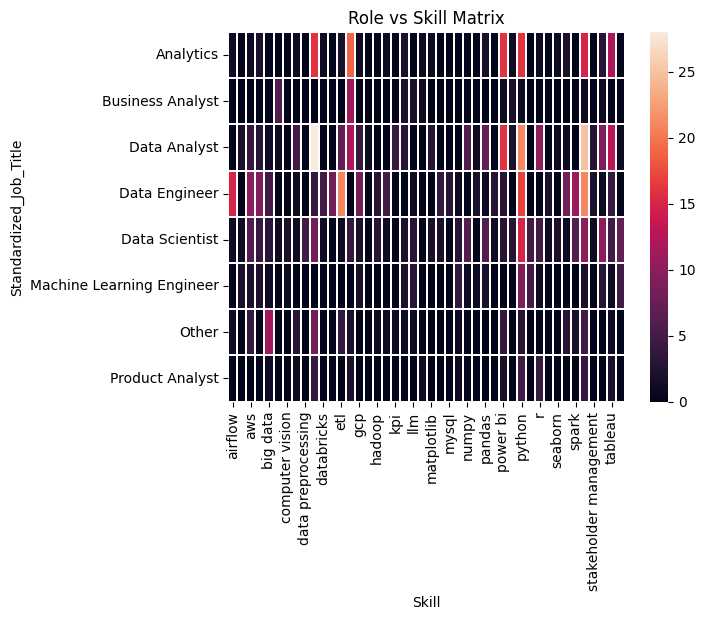

In [31]:
sns.heatmap(matrix , linewidth = 0.2 , linecolor = 'white')
plt.title("Role vs Skill Matrix")
plt.show()

### Normalized Skill Importance by Role
This chart shows the relative importance of skills within each role (normalized by total job postings for that role).

In [ ]:
def plot_normalized_skill_bar(role):
    subset = role_skill[role_skill["Standardized_Job_Title"] == role].sort_values("Normalized", ascending=False).head(10)
    if subset.empty:
        print(f"No skills found for role: {role}")
        return

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=subset,
        x="Normalized",
        y="Skill",
        hue= 'Skill',
        palette='plasma'
    )
    plt.title(f"Normalized Skill Importance for {role}")
    plt.xlabel("Normalized Importance (Skill Count / Total Role Postings)")
    plt.ylabel("Skill")
    plt.tight_layout()
    plt.show()

if use_widgets:
    normalized_dropdown = widgets.Dropdown(
        options=role_options,
        description="Role:",
        layout=widgets.Layout(width="60%")
    )
    widgets.interact(plot_normalized_skill_bar, role=normalized_dropdown)
else:
    selected_role = role_options[0]
    print(f"Select a role by changing `selected_role` and rerunning this cell.")
    print(f"Showing example for: {selected_role}")
    plot_normalized_skill_bar(selected_role)

interactive(children=(Dropdown(description='Role:', layout=Layout(width='60%'), options=('Analytics', 'Busines…